/tmp/ipykernel_9938/2013470447.py:28: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(


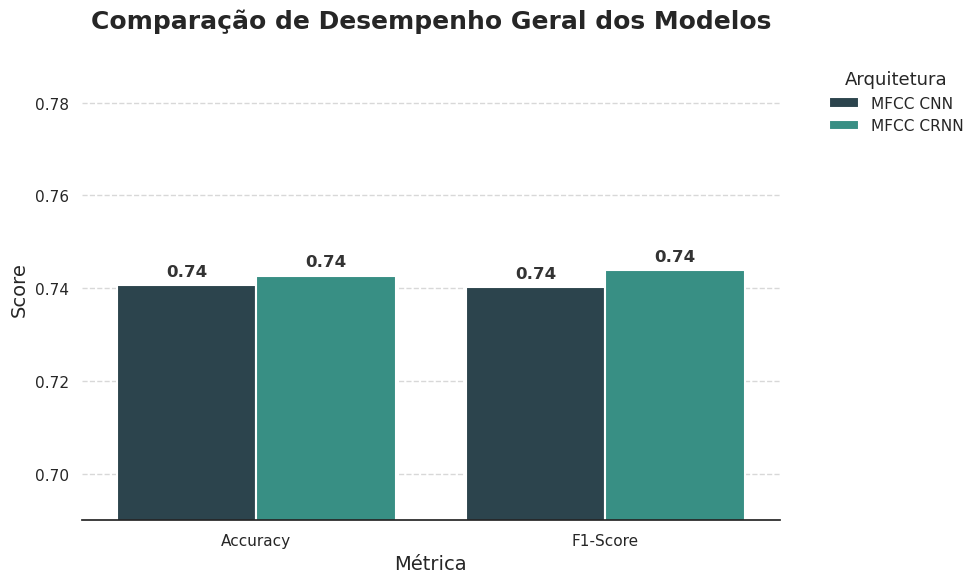

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('results/results.csv')

df_acc = df[df['Class/Metric'] == 'accuracy'][['Model', 'precision']].rename(columns={'precision': 'Accuracy'})
df_f1 = df[df['Class/Metric'] == 'weighted avg'][['Model', 'f1-score']].rename(columns={'f1-score': 'F1-Score'})

df_acc = df_acc.drop(df_acc[df_acc['Model'] == "Mel CNN"].index)
df_f1 = df_f1.drop(df_f1[df_f1['Model'] == "Mel CNN"].index)

df_gerais = pd.merge(df_acc, df_f1, on='Model')
df_gerais_melt = df_gerais.melt(id_vars='Model', var_name='Metric', value_name='Score')

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
plt.rcParams.update({
    'font.size': 12, 
    'axes.titlesize': 18, 
    'axes.labelsize': 14,
    'figure.autolayout': True
})

fig, ax = plt.subplots(figsize=(10, 6))

cores_customizadas = ['#264653', '#2a9d8f', '#e76f51']

sns.barplot(
    data=df_gerais_melt, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette=cores_customizadas, 
    ax=ax,
    edgecolor='white',
    linewidth=1.5
)

sns.despine(left=True, bottom=False)

ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3)
ax.set_axisbelow(True)

ymin = max(0, round(df_gerais_melt['Score'].min() - 0.05, 2))
ymax = min(1.0, round(df_gerais_melt['Score'].max() + 0.05, 2))
ax.set_ylim(ymin, ymax)

ax.set_title('Comparação de Desempenho Geral dos Modelos', fontweight='bold', pad=20)
ax.set_ylabel('Score')
ax.set_xlabel('Métrica')

for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.2f'), 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 10), 
        textcoords='offset points',
        fontsize=12,
        fontweight='bold',
        color='#333333'
    )

plt.legend(
    title='Arquitetura',
    title_fontsize='13',
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    frameon=False
)

plt.show()

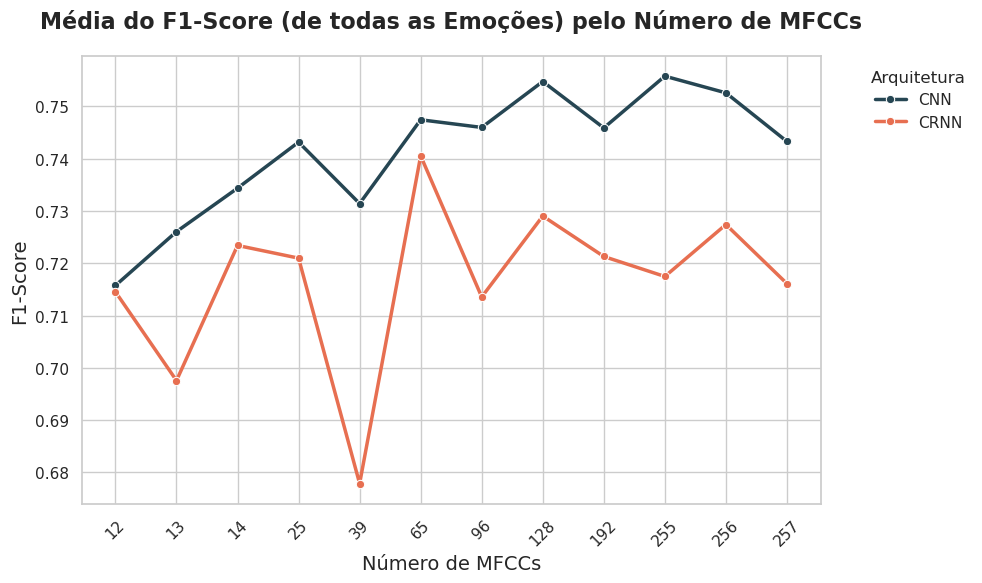

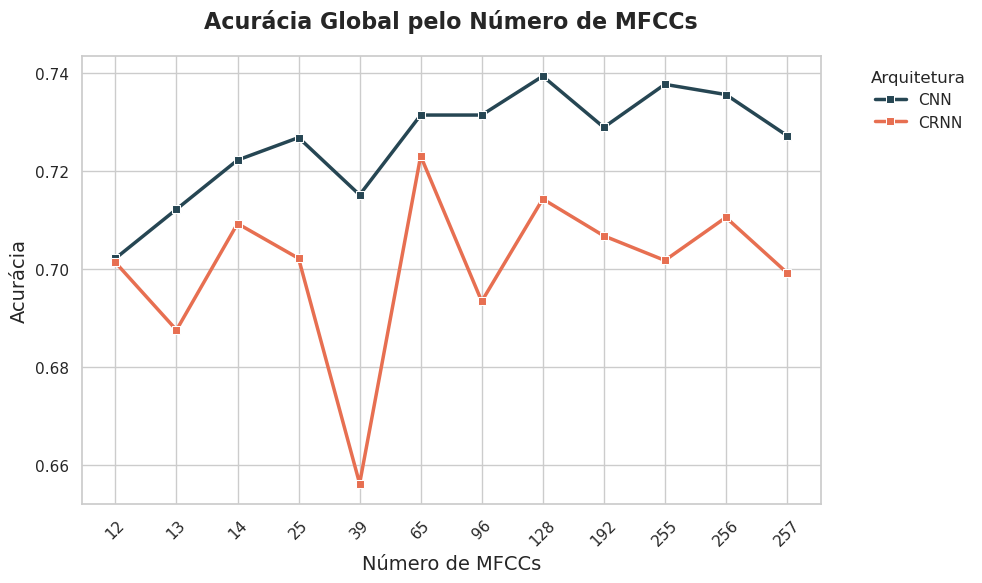

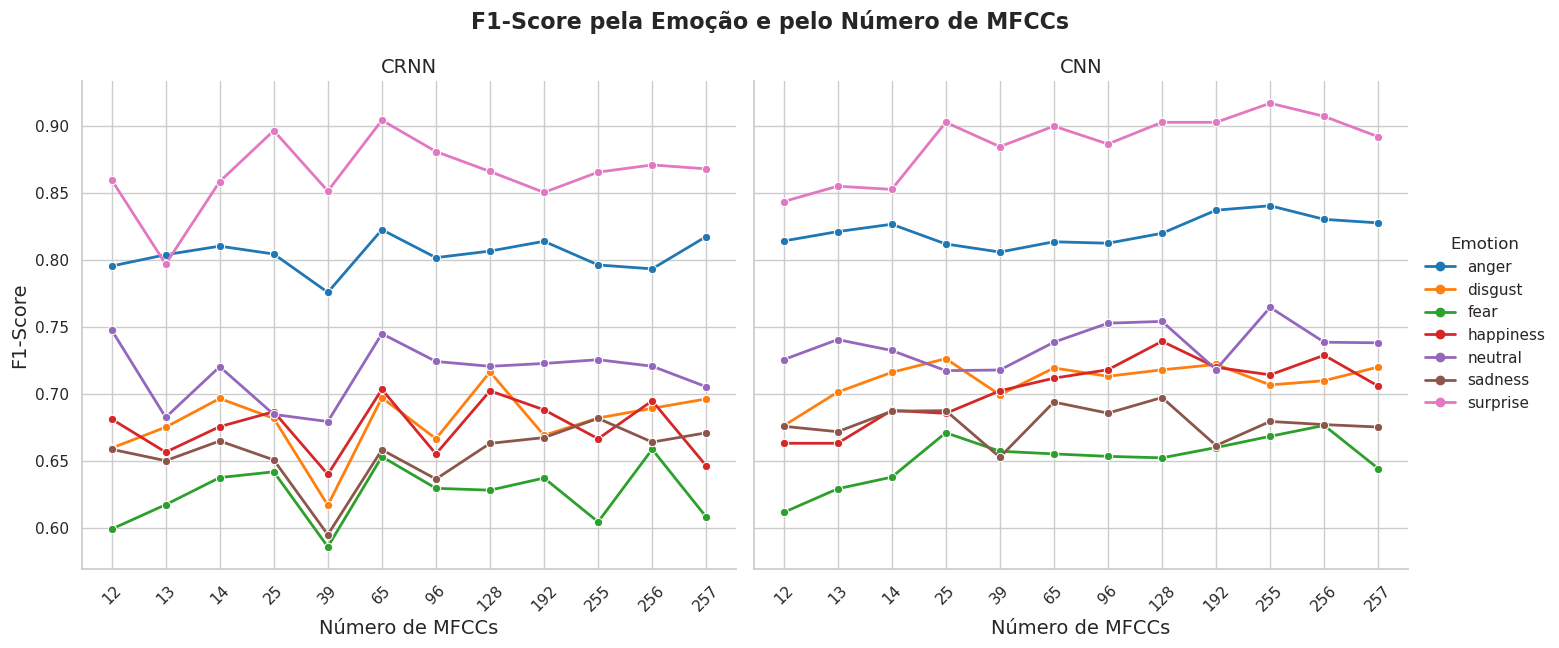

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv('results/results_consolidated.csv')

df_mfcc = df[df['Model'].str.contains('MFCC')].copy()

df_mfcc['Architecture'] = df_mfcc['Model'].apply(lambda x: 'CRNN' if 'CRNN' in x else 'CNN')
df_mfcc['N_MFCC'] = df_mfcc['Model'].str.extract(r'\((\d+)\)').astype(int)
df_mfcc = df_mfcc.sort_values('N_MFCC')

df_mfcc['N_MFCC_Cat'] = df_mfcc['N_MFCC'].astype(str)

sns.set_theme(style="whitegrid", rc={"axes.facecolor": (0, 0, 0, 0)})
plt.rcParams.update({
    'font.size': 12, 
    'axes.titlesize': 16, 
    'axes.labelsize': 14,
    'figure.autolayout': True
})

cores_arch = ['#264653', '#e76f51']

# =====================================================================
# GRÁFICO 1: Média do F1-Score de teste pelo número de MFCCs
# =====================================================================
df_f1_mean = df_mfcc[df_mfcc['Class/Metric'] == 'macro avg'].copy()

fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df_f1_mean, 
    x='N_MFCC_Cat', 
    y='f1-score', 
    hue='Architecture', 
    marker='o',
    palette=cores_arch,
    linewidth=2.5,
    ax=ax1
)

ax1.set_title('Média do F1-Score (de todas as Emoções) pelo Número de MFCCs', fontweight='bold', pad=20)
ax1.set_ylabel('F1-Score')
ax1.set_xlabel('Número de MFCCs')
ax1.tick_params(axis='x', rotation=45) 

plt.legend(title='Arquitetura', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.show()

# =====================================================================
# GRÁFICO 2: Média da Acurácia de teste pelo número de MFCCs
# =====================================================================
df_acc = df_mfcc[df_mfcc['Class/Metric'] == 'accuracy'].copy()
df_acc['Accuracy'] = df_acc['precision'].fillna(df_acc['f1-score'])

fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df_acc, 
    x='N_MFCC_Cat', 
    y='Accuracy', 
    hue='Architecture', 
    marker='s',
    palette=cores_arch,
    linewidth=2.5,
    ax=ax2
)

ax2.set_title('Acurácia Global pelo Número de MFCCs', fontweight='bold', pad=20)
ax2.set_ylabel('Acurácia')
ax2.set_xlabel('Número de MFCCs')
ax2.tick_params(axis='x', rotation=45)

plt.legend(title='Arquitetura', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.show()

# =====================================================================
# GRÁFICO 3: F1-Score pelo Tipo da Emoção e pelo número de MFCCs
# =====================================================================
metricas_gerais = ['accuracy', 'macro avg', 'weighted avg']
df_emotions = df_mfcc[~df_mfcc['Class/Metric'].isin(metricas_gerais)].copy()
df_emotions.rename(columns={'Class/Metric': 'Emotion'}, inplace=True)

g = sns.relplot(
    data=df_emotions,
    x='N_MFCC_Cat', 
    y='f1-score',
    hue='Emotion',
    col='Architecture',
    kind='line',
    marker='o',
    linewidth=2,
    height=6,
    aspect=1.2,
    palette='tab10'
)

g.fig.suptitle('F1-Score pela Emoção e pelo Número de MFCCs', fontweight='bold', y=1.05, fontsize=16)
g.set_axis_labels("Número de MFCCs", "F1-Score")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.show()